# Loan Approval Prediction Using Data Analytics and Machine Learning

## Project Overview

This project focuses on analyzing loan application data and building a machine learning model to predict whether a loan application will be approved or rejected.

The project includes data cleaning, exploratory data analysis (EDA), data visualization, feature engineering, machine learning model development, model evaluation, and loan approval prediction.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Data/loan_approval_dataset.csv")

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.shape

(4269, 13)

In [5]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [7]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [8]:
df.columns = df.columns.str.strip()

In [9]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [10]:
# Checking Missing Values
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [12]:
# Checking Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [13]:
# Loan Status Distribution
df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [14]:
# Loan Status Percentage
df["loan_status"].value_counts(normalize=True) * 100

loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64

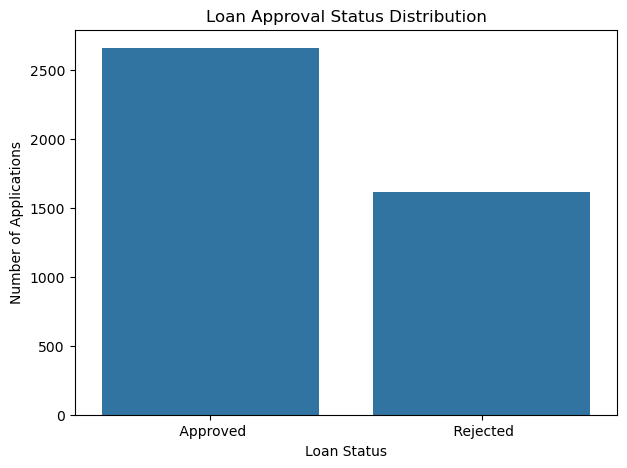

In [15]:
# Loan Status Distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="loan_status")

plt.title("Loan Approval Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

### Observation

The dataset contains 4,269 loan applications. Out of these, 2,656 applications (62.22%) were approved, while 1,613 applications (37.78%) were rejected. This shows that approved applications are more frequent than rejected applications in the dataset.

In [16]:
# Numerical Features

numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount',
       'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

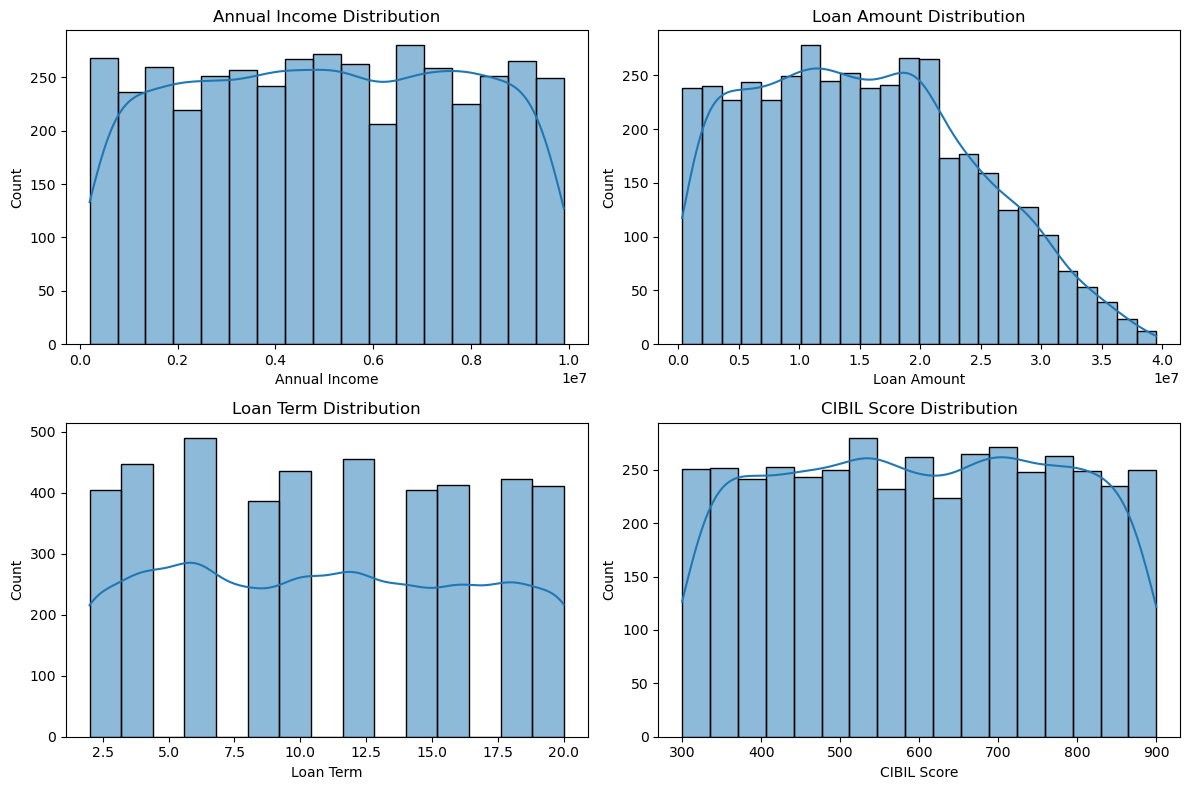

In [17]:
# Distribution of Important Numerical Features

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["income_annum"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Annual Income Distribution")
axes[0, 0].set_xlabel("Annual Income")

sns.histplot(df["loan_amount"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Loan Amount Distribution")
axes[0, 1].set_xlabel("Loan Amount")

sns.histplot(df["loan_term"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Loan Term Distribution")
axes[1, 0].set_xlabel("Loan Term")

sns.histplot(df["cibil_score"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("CIBIL Score Distribution")
axes[1, 1].set_xlabel("CIBIL Score")

plt.tight_layout()
plt.show()

### Observations

- Annual income values are distributed across a broad range in the dataset.
- Loan amounts are more concentrated toward the lower and middle ranges, with fewer applications at higher loan amounts.
- Loan terms vary across different repayment periods from approximately 2 to 20 years.
- CIBIL scores cover a wide range from approximately 300 to 900, representing applicants with different credit profiles.

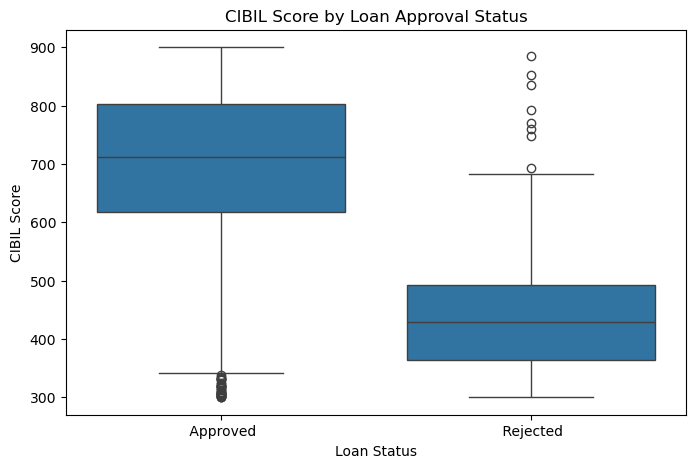

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="loan_status", y="cibil_score")

plt.title("CIBIL Score by Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("CIBIL Score")

plt.show()

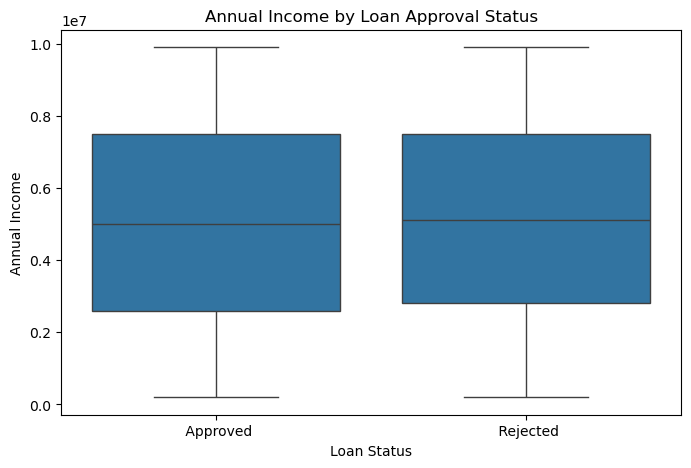

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="loan_status", y="income_annum")

plt.title("Annual Income by Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")

plt.show()

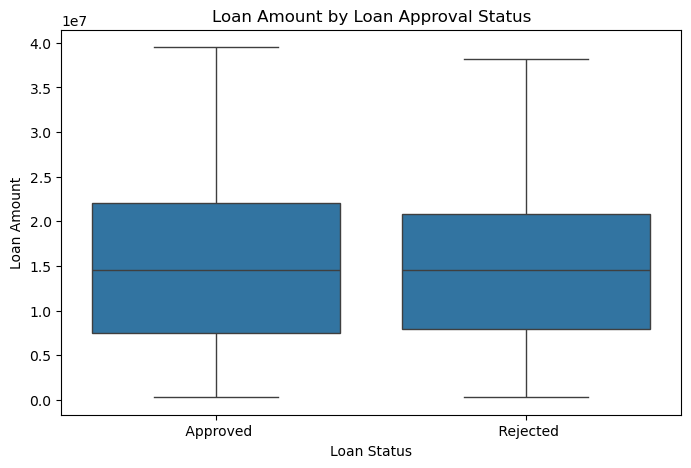

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="loan_status", y="loan_amount")

plt.title("Loan Amount by Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")

plt.show()

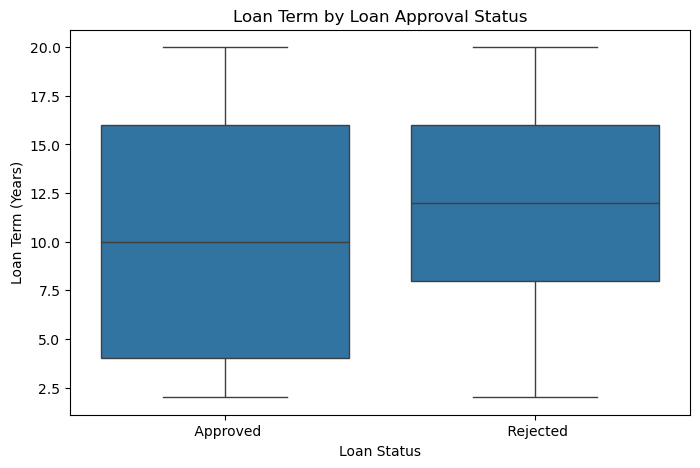

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="loan_status", y="loan_term")

plt.title("Loan Term by Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Term (Years)")

plt.show()

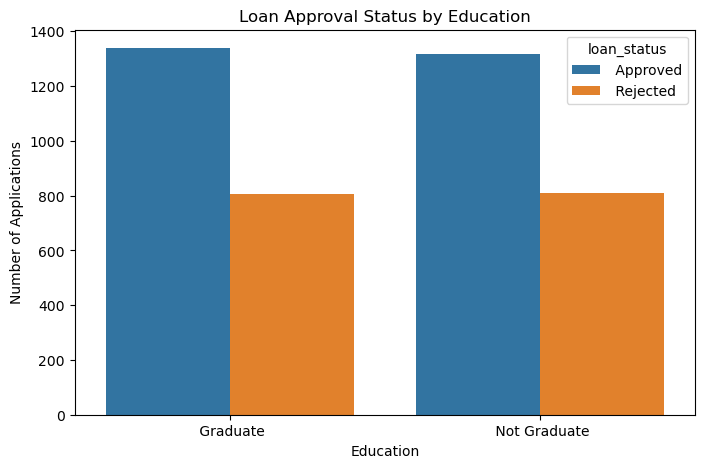

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="education", hue="loan_status")

plt.title("Loan Approval Status by Education")
plt.xlabel("Education")
plt.ylabel("Number of Applications")

plt.show()

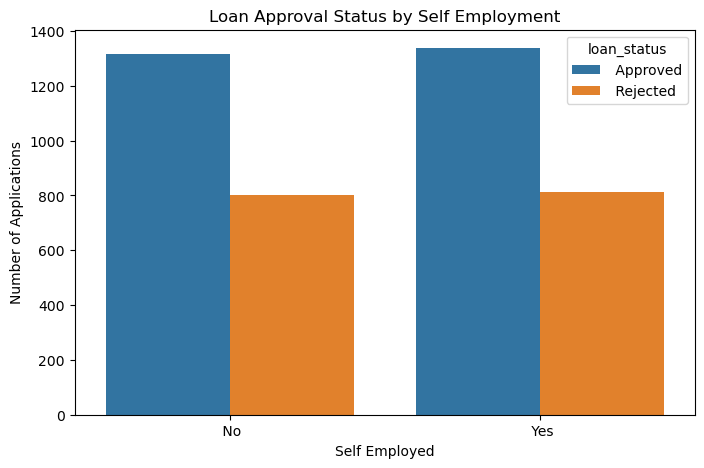

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="self_employed", hue="loan_status")

plt.title("Loan Approval Status by Self Employment")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applications")

plt.show()

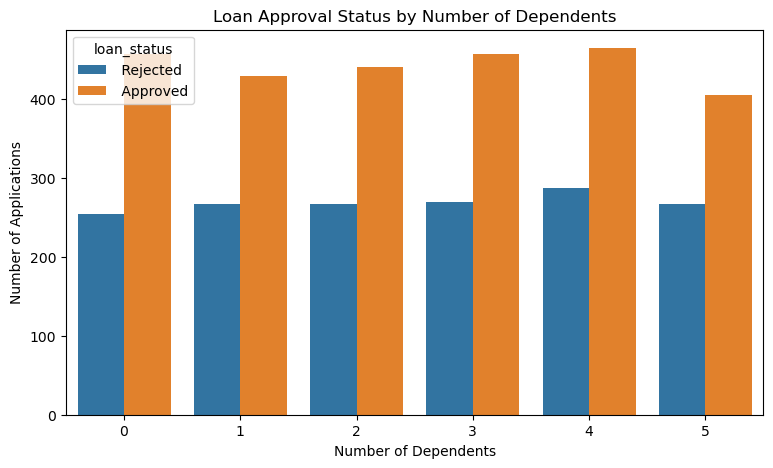

In [26]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="no_of_dependents", hue="loan_status")

plt.title("Loan Approval Status by Number of Dependents")
plt.xlabel("Number of Dependents")
plt.ylabel("Number of Applications")

plt.show()

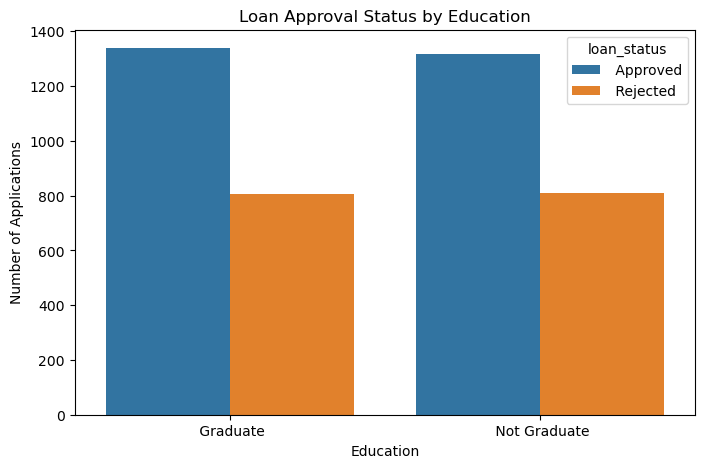

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="education", hue="loan_status")

plt.title("Loan Approval Status by Education")
plt.xlabel("Education")
plt.ylabel("Number of Applications")

plt.show()

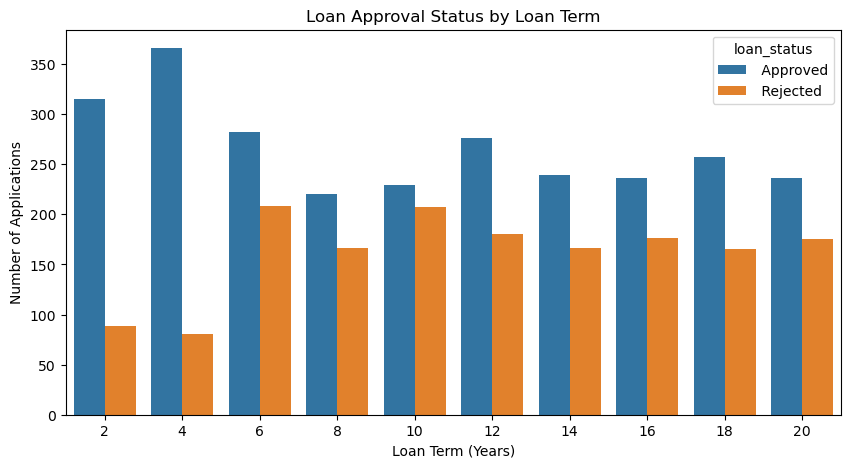

In [28]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="loan_term", hue="loan_status")

plt.title("Loan Approval Status by Loan Term")
plt.xlabel("Loan Term (Years)")
plt.ylabel("Number of Applications")

plt.show()

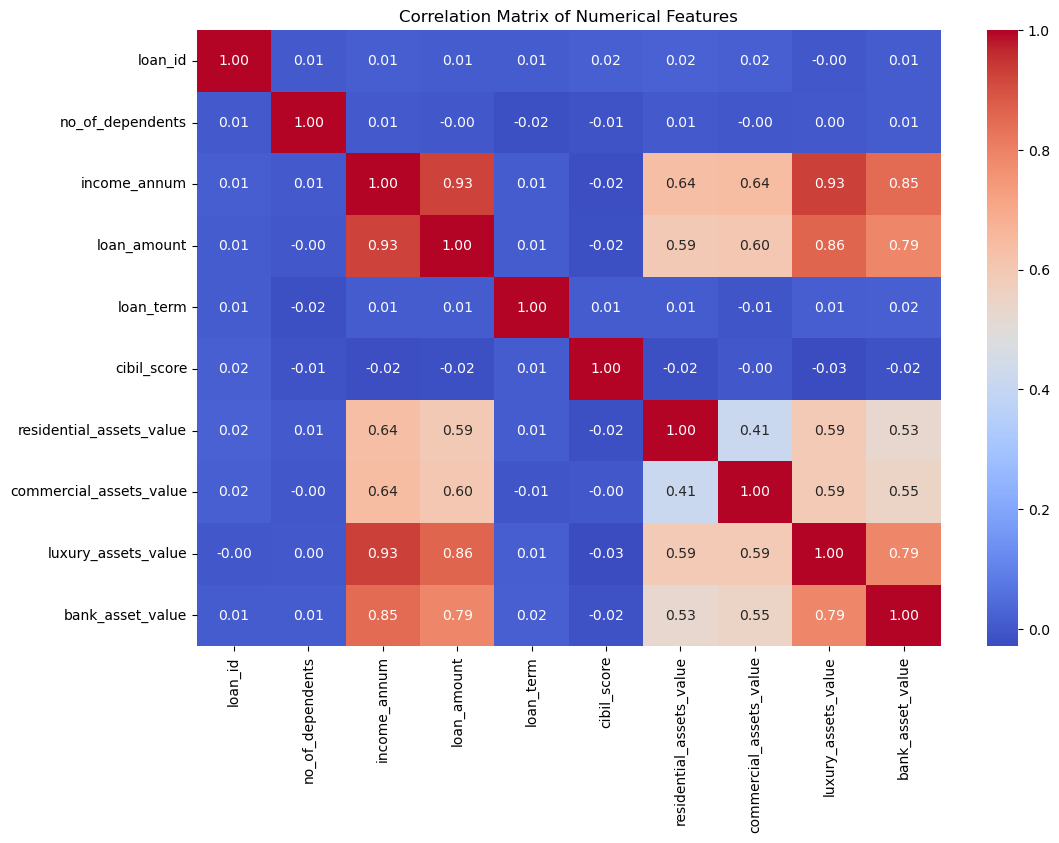

In [29]:
# Correlation Matrix

plt.figure(figsize=(12, 8))

correlation_matrix = df[numerical_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

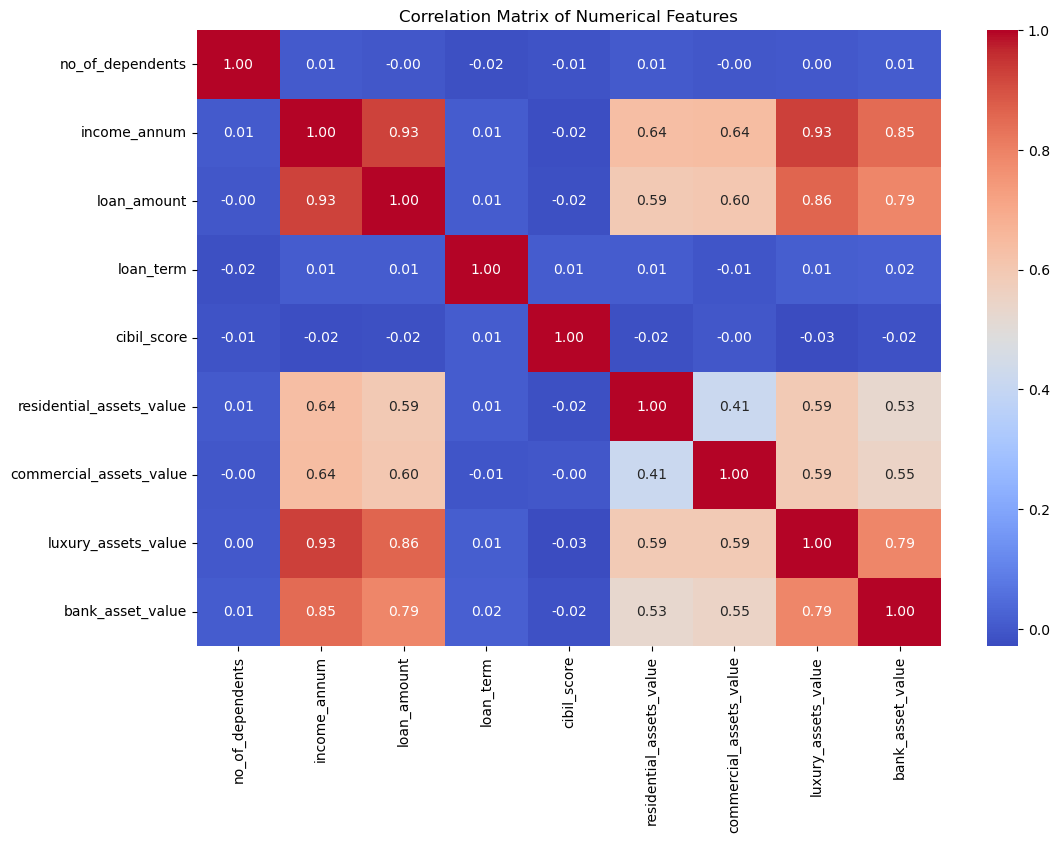

In [30]:
correlation_columns = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

plt.figure(figsize=(12, 8))

correlation_matrix = df[correlation_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Observation

The correlation matrix shows strong positive relationships among several financial features. Annual income has a strong correlation with loan amount (0.93), luxury assets value (0.93), and bank asset value (0.85). Loan amount also shows strong relationships with luxury assets value (0.86) and bank asset value (0.79). In contrast, CIBIL score, loan term, and number of dependents have relatively weak correlations with most other numerical features.

In [31]:
df["loan_status"].unique()

array([' Approved', ' Rejected'], dtype=object)

In [32]:
# Encoding Loan Status

df["loan_status_encoded"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

df[["loan_status", "loan_status_encoded"]].head()

,loan_status,loan_status_encoded
0,Approved,NaN
1,Rejected,NaN
2,Rejected,NaN
3,Rejected,NaN
4,Rejected,NaN


In [33]:
df["loan_status_encoded"].value_counts()

Series([], Name: count, dtype: int64)

In [34]:
df["loan_status"].unique()

array([' Approved', ' Rejected'], dtype=object)

In [35]:
df["loan_status"] = df["loan_status"].str.strip()

In [36]:
df["loan_status"].unique()

array(['Approved', 'Rejected'], dtype=object)

In [37]:
df["loan_status_encoded"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

In [38]:
df[["loan_status", "loan_status_encoded"]].head()

,loan_status,loan_status_encoded
0,Approved,1
1,Rejected,0
2,Rejected,0
3,Rejected,0
4,Rejected,0


In [39]:
df["loan_status_encoded"].value_counts()

loan_status_encoded
1    2656
0    1613
Name: count, dtype: int64

In [40]:
# Average values by loan status

df.groupby("loan_status")[[
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]].mean()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
loan_status,,,,,,,,,
Approved,2.474774,5.025904e+06,1.524725e+07,10.397590,703.461973,7.399812e+06,5.001355e+06,1.501660e+07,4.959526e+06
Rejected,2.538128,5.113825e+06,1.494606e+07,11.728456,429.468072,7.592498e+06,4.926720e+06,1.530694e+07,5.004960e+06


In [41]:
df.groupby("loan_status")["cibil_score"].mean()

loan_status
Approved    703.461973
Rejected    429.468072
Name: cibil_score, dtype: float64

In [42]:
df.groupby("loan_status")["income_annum"].mean()

loan_status
Approved    5.025904e+06
Rejected    5.113825e+06
Name: income_annum, dtype: float64

In [43]:
# Categorical Features

categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['education', 'self_employed', 'loan_status'], dtype='object')

In [44]:
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


education:
[' Graduate' ' Not Graduate']

self_employed:
[' No' ' Yes']

loan_status:
['Approved' 'Rejected']


In [45]:
# Features and Target

X = df.drop(columns=["loan_status", "loan_status_encoded", "loan_id"])
y = df["loan_status_encoded"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4269, 11)
Target shape: (4269,)


In [46]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [47]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: loan_status_encoded, dtype: int64

In [48]:
# Encode Categorical Features

X = pd.get_dummies(
    X,
    columns=["education", "self_employed"],
    drop_first=True,
    dtype=int
)

X.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,0
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,1
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,1


# Train-Test Split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3415, 11)
Testing data: (854, 11)


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (3415, 11)
Scaled testing data shape: (854, 11)


In [52]:
scaler.fit_transform(X_train)

array([[ 0.89071783, -0.09264606, -0.08867674, ..., -0.73682658,
        -0.99853694, -1.00852831],
       [ 0.30110717,  0.26545952,  0.18021761, ..., -0.39679525,
        -0.99853694,  0.99154381],
       [-0.28850349,  1.08910236,  0.80763775, ...,  0.71603457,
        -0.99853694,  0.99154381],
       ...,
       [ 0.30110717,  0.08640673,  0.31466478, ..., -0.42770719,
        -0.99853694,  0.99154381],
       [-1.46772481, -0.23588829, -0.1110846 , ...,  0.37600323,
        -0.99853694, -1.00852831],
       [ 0.30110717,  1.33977627,  0.59476306, ...,  2.10707184,
        -0.99853694, -1.00852831]])

In [53]:
scaler.transform(X_test)

array([[ 0.30110717,  1.16072348,  1.82719548, ...,  0.3450913 ,
         1.0014652 ,  0.99154381],
       [ 0.89071783, -0.70142554, -0.77211653, ..., -0.58226688,
         1.0014652 ,  0.99154381],
       [-0.87811415,  1.0532918 ,  1.88321513, ...,  0.31417936,
        -0.99853694, -1.00852831],
       ...,
       [ 0.89071783, -0.12845661, -0.45840646, ...,  0.59238681,
        -0.99853694,  0.99154381],
       [ 1.48032849, -1.70412117, -1.56759564, ..., -1.41688925,
        -0.99853694, -1.00852831],
       [ 0.30110717,  1.01748124,  1.58070899, ...,  0.59238681,
        -0.99853694,  0.99154381]])

In [54]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [55]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))

Logistic Regression Results
---------------------------
Accuracy : 0.9133489461358314
Precision: 0.9208103130755064
Recall   : 0.9416195856873822
F1 Score : 0.931098696461825


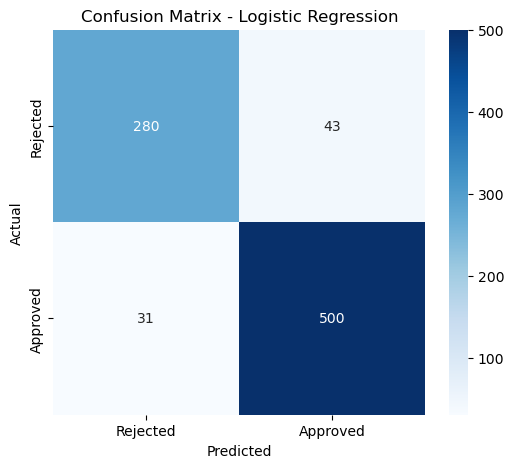

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [59]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [60]:
y_pred_tree = decision_tree_model.predict(X_test)

In [61]:
print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1 Score :", f1_score(y_test, y_pred_tree))

Decision Tree Results
---------------------
Accuracy : 0.9836065573770492
Precision: 0.983177570093458
Recall   : 0.9905838041431262
F1 Score : 0.9868667917448405


In [62]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [63]:
y_pred_rf = random_forest_model.predict(X_test)

In [64]:
print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.9812646370023419
Precision: 0.9831144465290806
Recall   : 0.9868173258003766
F1 Score : 0.9849624060150376


# Model Comparison

In [65]:
# Model Comparison

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.913349,0.920810,0.941620,0.931099
1,Decision Tree,0.983607,0.983178,0.990584,0.986867
2,Random Forest,0.981265,0.983114,0.986817,0.984962


<Figure size 1000x600 with 0 Axes>

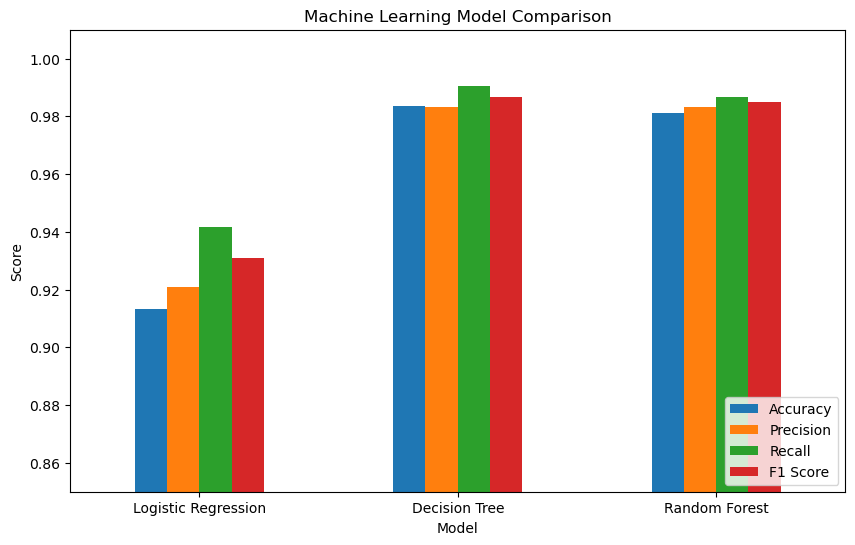

In [66]:
plt.figure(figsize=(10, 6))

model_results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

### Model Comparison

Three machine learning models were evaluated using accuracy, precision, recall, and F1 score. Logistic Regression achieved lower scores compared with the tree-based models. Decision Tree and Random Forest both achieved high performance, with the Decision Tree obtaining the highest scores across the evaluated metrics on the test set.

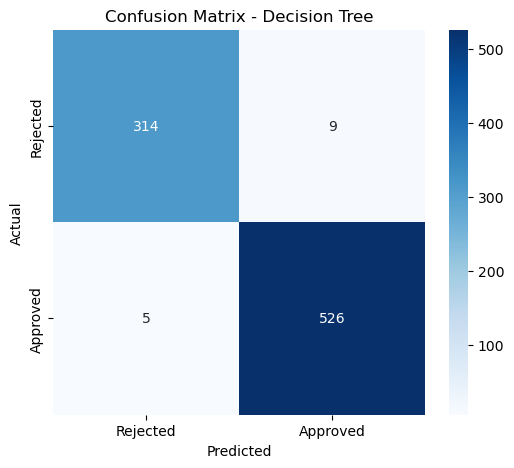

In [67]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [68]:
# Feature Importance - Decision Tree

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": decision_tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,cibil_score,0.814802
3,loan_term,0.083869
2,loan_amount,0.046412
1,income_annum,0.032226
7,luxury_assets_value,0.011229
5,residential_assets_value,0.005995
0,no_of_dependents,0.004005
8,bank_asset_value,0.000831
6,commercial_assets_value,0.000632
9,education_ Not Graduate,0.000000


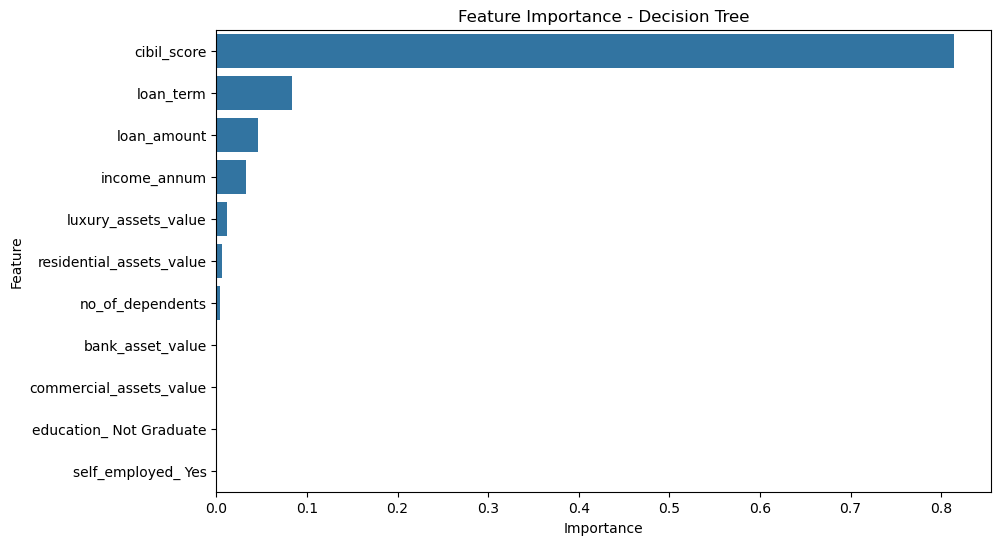

In [69]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [75]:
import joblib

joblib.dump(decision_tree_model, "loan_approval_model.pkl")

['loan_approval_model.pkl']

In [74]:
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [76]:
import joblib

model = joblib.load("loan_approval_model.pkl")
feature_names = joblib.load("feature_names.pkl")

print("Model loaded successfully!")
print("Features:")
print(feature_names)

Model loaded successfully!
Features:
['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'education_ Not Graduate', 'self_employed_ Yes']


In [80]:
sample_applicant = pd.DataFrame({
    "no_of_dependents": [2],
    "income_annum": [8000000],
    "loan_amount": [20000000],
    "loan_term": [10],
    "cibil_score": [750],
    "residential_assets_value": [5000000],
    "commercial_assets_value": [3000000],
    "luxury_assets_value": [10000000],
    "bank_asset_value": [7000000],
    "education_ Not Graduate": [0],
    "self_employed_ Yes": [0]
})

sample_applicant = sample_applicant[feature_names]

sample_applicant

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
0,2,8000000,20000000,10,750,5000000,3000000,10000000,7000000,0,0


In [81]:
prediction = model.predict(sample_applicant)

if prediction[0] == 1:
    print("Loan Status: Approved")
else:
    print("Loan Status: Rejected")

Loan Status: Approved


In [83]:
probability = model.predict_proba(sample_applicant)

print("Rejected Probability:", probability[0][0])
print("Approved Probability:", probability[0][1])

Rejected Probability: 0.0
Approved Probability: 1.0


### Prediction Demo

A sample loan application was provided to the trained Decision Tree model. Based on the given applicant details, the model predicted the loan status as **Approved**.

The model returned an approved-class probability of 1.0 for this sample.

# Key Insights

1. The dataset contains 4,269 loan applications, with 62.22% approved and 37.78% rejected applications.

2. CIBIL score shows a clear difference between approved and rejected applications. Approved applications generally have higher CIBIL scores.

3. Annual income and loan amount distributions are broadly similar between approved and rejected applications.

4. Several financial variables show strong positive correlations. Annual income has a strong correlation with loan amount (0.93), while income also has strong relationships with luxury assets (0.93) and bank assets (0.85).

5. The Decision Tree model identified CIBIL score as the most important feature, with an importance of approximately 0.81.

6. Among the three evaluated models, Decision Tree achieved the highest performance on the test set, with approximately 98.36% accuracy and 98.69% F1 score.

7. The prediction demo successfully classified a sample loan application as Approved.

# Final Model

Three classification models were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Based on the evaluation results on the test dataset, the Decision Tree achieved the highest scores among the three models.

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 91.33% | 92.08% | 94.16% | 93.11% |
| Decision Tree | 98.36% | 98.32% | 99.06% | 98.69% |
| Random Forest | 98.13% | 98.31% | 98.82% | 98.50% |

Therefore, the Decision Tree model was selected as the final model for the prediction demonstration.

# Conclusion

This project analyzed loan application data and developed machine learning models to predict loan approval status.

The analysis included data cleaning, exploratory data analysis, visualization, feature engineering, model training, and evaluation. Three classification algorithms were tested: Logistic Regression, Decision Tree, and Random Forest.

The Decision Tree model achieved the highest performance on the test set, with an accuracy of approximately 98.36% and an F1 score of approximately 98.69%. The feature importance analysis also showed that CIBIL score was the most influential feature in the trained Decision Tree model.

The project demonstrates how data analytics and machine learning can be applied to loan application data to identify patterns and support automated loan approval predictions.

# Limitations

- The model was trained and evaluated on a single dataset.
- Model performance may differ on new or real-world loan applications.
- The feature importance values describe the behavior of the trained model and do not establish causation.
- The prediction system should be treated as a decision-support tool rather than a replacement for a complete loan approval process.